In [43]:
#imports
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

from sklearn.metrics import precision_score, recall_score, f1_score, balanced_accuracy_score

from xgboost import XGBClassifier

import optuna as opt
from optuna.integration import XGBoostPruningCallback

from sklearn.metrics import ConfusionMatrixDisplay


In [3]:
data = pd.read_csv("../data/creditcard.csv")
print(data.shape)
data.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Data Cleaning

In [4]:
# Here time is the seconds enlapsed since the first transaction. 
# From domain knowlege, it should not correlate to a fraudulent transaction.
print(data["Time"].corr(data["Class"]))

#No correlation so drop the column
data_prepped = data.drop(columns="Time")

-0.012322570929245623


In [5]:
data_prepped.describe()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,2.239053e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,1.088850e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,-2.458826e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,-5.354257e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,-9.291738e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,4.539234e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,2.374514e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [ ]:
#check for missing values
data_prepped.isnull().sum()

V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [7]:
#High class imbalance
data_prepped["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

### ML models

#### Data Prep

In [ ]:
# Split input features and output classes
X = data_prepped.drop(columns="Class")
y = data_prepped.loc[:,"Class"]

In [ ]:
# Train and test data split into 80% train and 20% test set.
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
# Train class distribution
y_train.value_counts()

Class
0    227451
1       394
Name: count, dtype: int64

In [ ]:
# Test class distribution
y_test.value_counts()

Class
0    56864
1       98
Name: count, dtype: int64

In [ ]:
#Scaling the data before SMOTE. Fit the scaler only with the train data to prevent data leakage.
# Scaling is important because SMOTE works based on KNN which is sensitive to scale.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Class imbalance

In [ ]:
#Since the data has high class imbalance, it is better to apply both upsample and down sample.
# Upsample to 0.5 ratio and then down sample to match it.
#This produces better results in the case of high imbalance by reducing the chance of duplication.
smote = SMOTE(sampling_strategy=0.5,random_state=42)

In [ ]:
#Upsample
X_train_scaled_smote,y_train_smote = smote.fit_resample(X_train_scaled,y_train)

In [ ]:
#0.5 ratio upsampling
y_train_smote.value_counts()

Class
0    227451
1    113725
Name: count, dtype: int64

In [ ]:
#under sampling
under_sample = RandomUnderSampler(random_state=42)

In [17]:
X_train_balanced,y_train_balanced = under_sample.fit_resample(X_train_scaled_smote,y_train_smote)

In [ ]:
# Finally removing imbalance.
y_train_balanced.value_counts()

Class
0    113725
1    113725
Name: count, dtype: int64

#### Random Forest

In [39]:
# Random forest classification
rf = RandomForestClassifier(random_state=42)

In [40]:
# Fit the model
rf.fit(X_train_balanced,y_train_balanced)

RandomForestClassifier(random_state=42)

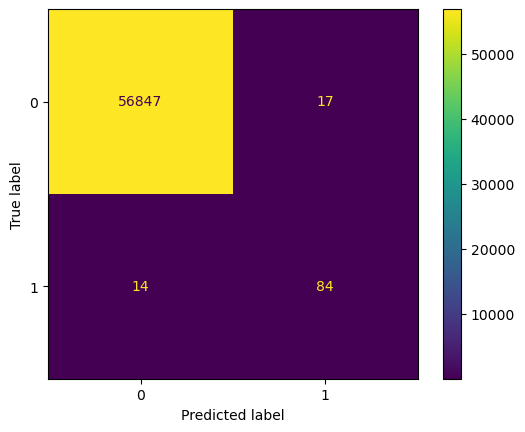

In [42]:
#confusion matrix for Random Forest
rf_pred = rf.predict(X_test_scaled)
cm=confusion_matrix(y_test,rf_pred,labels=rf.classes_)
 
color = 'white'
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot()
plt.show()

In [ ]:
print("Precision Score:",precision_score(y_test,rf_pred))
print("Recall Score:",recall_score(y_test,rf_pred))

Precision Score: 0.8316831683168316
Recall Score: 0.8571428571428571


#### XGBoost Classifier

In [ ]:
# XGBoost classifier
xgb = XGBClassifier(random_state=42)

In [ ]:
#Fit the model
xgb.fit(X_train_balanced,y_train_balanced)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

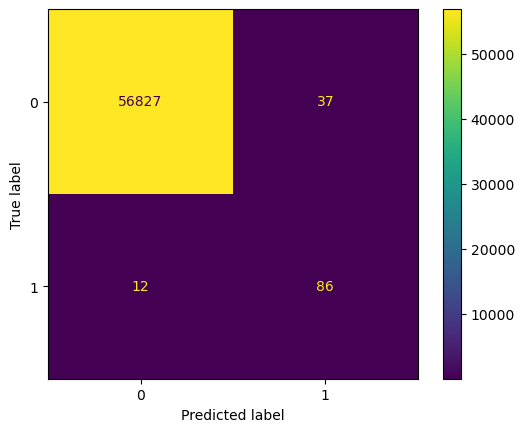

In [41]:
#confusion matrix for Random Forest
xgb_pred = xgb.predict(X_test_scaled)
cm=confusion_matrix(y_test,xgb_pred,labels=xgb.classes_)
 
color = 'white'
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=xgb.classes_)
disp.plot()
plt.show()

In [22]:
print("Precision Score:",precision_score(y_test,xgb_pred))
print("Recall Score:",recall_score(y_test,xgb_pred))
print("F1 Score:",f1_score(y_test,xgb_pred))

Precision Score: 0.6991869918699187
Recall Score: 0.8775510204081632
F1 Score: 0.7782805429864255


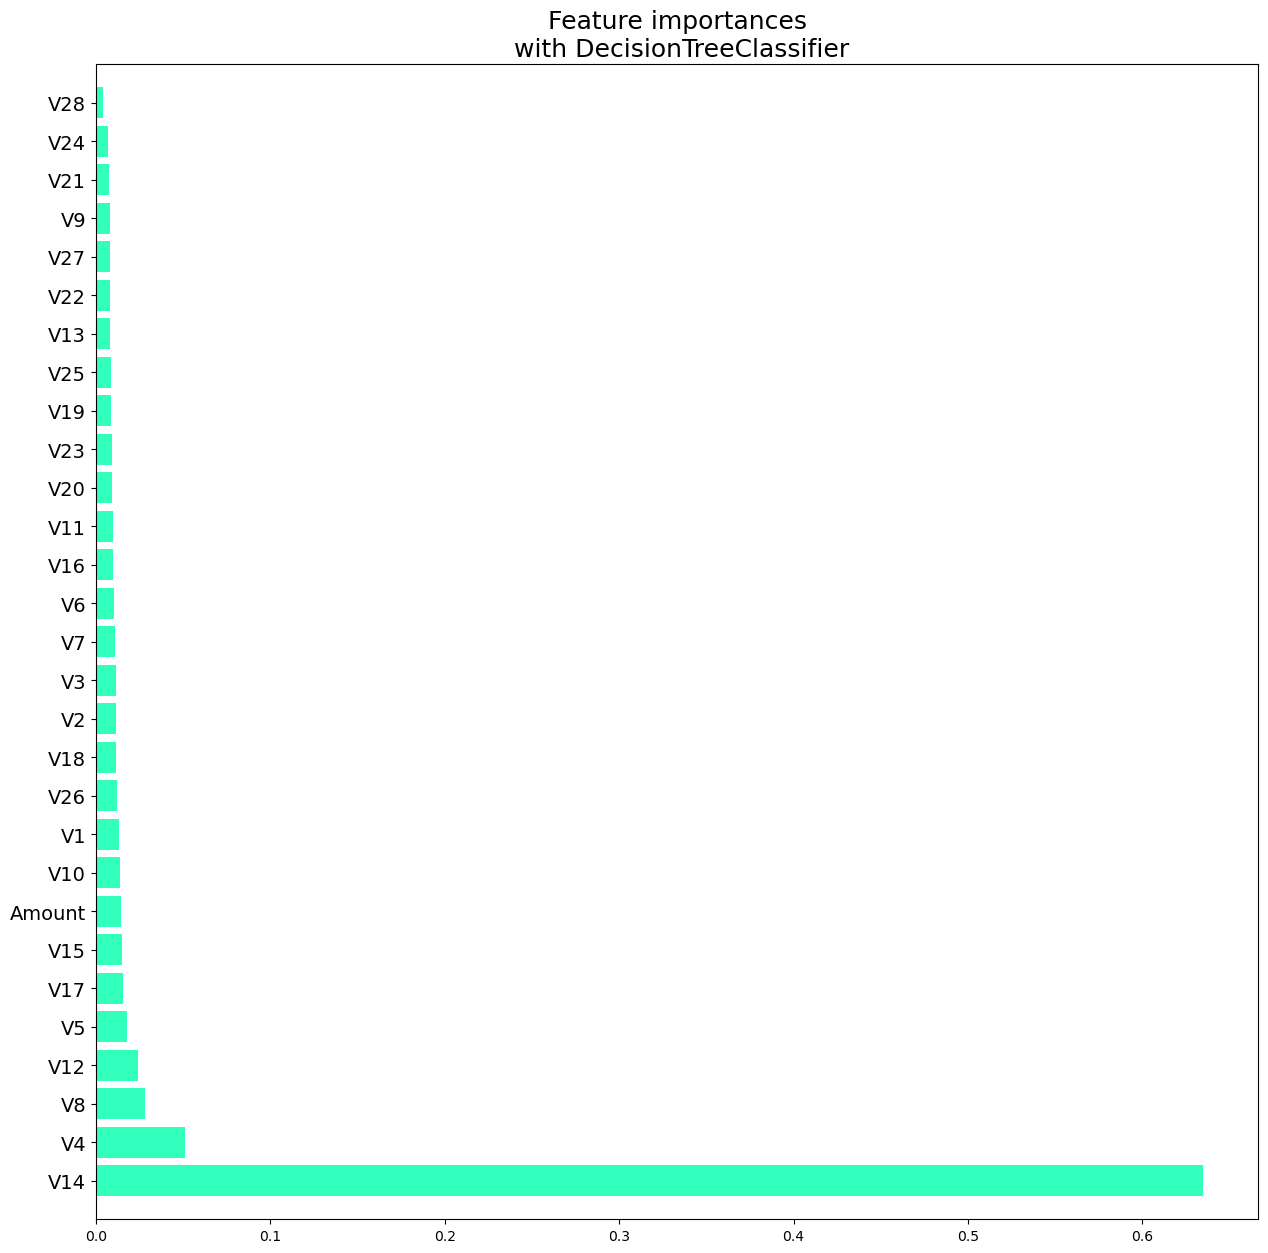

In [23]:
#important features plot
importances = xgb.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

# Plot the feature importances of the forest
def feature_importance(indices, importances, feature_names):
    plt.figure(figsize=(15,15))
    plt.title(" Feature importances \n with DecisionTreeClassifier", fontsize=18)
    plt.barh(range(len(indices)), importances[indices], color='#33FFBD',  align="center")
    plt.yticks(range(len(indices)), feature_names[indices], rotation='horizontal',fontsize=14)
    plt.ylim([-1, len(indices)])

feature_importance(indices, importances, feature_names)
plt.show()

#### Optuna Hyper-parameter Tuning

In [24]:
#f1 scorer for XGBoost
def f1_scorer(y_true,y_pred):
    """returns the 1 - f1 score score that must be minimized by XGBoost

    Args:
        y_true (pandas.DataFrame,numpy.ndarray): true validation labels
        y_pred (pandas.DataFrame,numpy.ndarray): predicted validation labels

    Returns:
        float: 1-f1_score
    """
    y_pred=np.round(y_pred)
    return 1-f1_score(y_true,y_pred)

In [25]:
#hyper-parameter tuning on one train and validation set
def objective_xgboost(trial,X_train,y_train,X_valid,y_valid):
    """an objective function for optuna to maximize the balanced accuracy

    Args:
        X_train: input labels of training data
        y_train: output labels of training data
        X_valid: input labels of validation data
        y_valid: output labels of validation data

    Returns:
        float: score of a trail
    """

    # -- XGBClassifier parameters
    param=dict(
        n_estimators=trial.suggest_int('n_estimators',2,1000),
        learning_rate=trial.suggest_float('learning_rate',0.01,0.5,step=0.01),
        max_depth=trial.suggest_int('max_depth',3,10),
        min_child_weight = trial.suggest_int('min_child_weight',1,6),
        gamma=trial.suggest_float('gamma',0,0.2,step=0.01),
        subsample=trial.suggest_float('subsample',0.5,0.9,step=0.01),
        colsample_bytree=trial.suggest_float('colsample_bytree',0.5,0.9,step=0.01),
        reg_lambda=trial.suggest_float('reg_lambda',0,0.1,step=0.001),
        scale_pos_weight=trial.suggest_int('scale_pos_weight',1,10)
        )          
    # -- fit model with pruning mechanism that stops early if the model does not do better than last trail.
    pruining_callback=XGBoostPruningCallback(trial, "validation_0-f1_scorer")
    model=XGBClassifier(objective='binary:logistic',**param,random_state=42,n_jobs=2,eval_metric=f1_scorer,callbacks=[pruining_callback],early_stopping_rounds=50,verbosity=0)
    
    # -- Fit model and evaluate score
    model.fit(X_train,y_train,eval_set=[(X_valid,y_valid)],verbose=0)
    score=1-model.best_score
    return score

In [26]:
X_train_opt,X_valid,y_train_opt,y_valid = train_test_split(X_train_balanced,y_train_balanced,test_size=0.2,random_state=42)

In [27]:
#create a study of 100 trials
study=opt.create_study(study_name='xgboost optimization_pruned',direction="maximize", sampler=opt.samplers.TPESampler(seed=0), pruner=opt.pruners.HyperbandPruner())
#optimize XGBoost by maximizing the score
study.optimize(lambda trial: objective_xgboost(trial,X_train_opt,y_train_opt,X_valid,y_valid), n_trials=20,n_jobs=2)

[I 2025-04-30 22:04:14,794] A new study created in memory with name: xgboost optimization_pruned
[I 2025-04-30 22:04:22,567] Trial 0 finished with value: 0.999651 and parameters: {'n_estimators': 374, 'learning_rate': 0.14, 'max_depth': 8, 'min_child_weight': 3, 'gamma': 0.15, 'subsample': 0.9, 'colsample_bytree': 0.5700000000000001, 'reg_lambda': 0.018000000000000002, 'scale_pos_weight': 6}. Best is trial 0 with value: 0.999651.
[I 2025-04-30 22:04:23,335] Trial 1 finished with value: 0.99976 and parameters: {'n_estimators': 911, 'learning_rate': 0.23, 'max_depth': 8, 'min_child_weight': 3, 'gamma': 0.18, 'subsample': 0.54, 'colsample_bytree': 0.77, 'reg_lambda': 0.081, 'scale_pos_weight': 2}. Best is trial 1 with value: 0.99976.
[I 2025-04-30 22:04:25,014] Trial 2 finished with value: 0.999323 and parameters: {'n_estimators': 63, 'learning_rate': 0.37, 'max_depth': 9, 'min_child_weight': 6, 'gamma': 0.14, 'subsample': 0.75, 'colsample_bytree': 0.63, 'reg_lambda': 0.083, 'scale_pos_we

In [28]:
#best parameters after hyper-parameter tuning
study.best_params

{'n_estimators': 911,
 'learning_rate': 0.23,
 'max_depth': 8,
 'min_child_weight': 3,
 'gamma': 0.18,
 'subsample': 0.54,
 'colsample_bytree': 0.77,
 'reg_lambda': 0.081,
 'scale_pos_weight': 2}

In [29]:
#balanced accuracy scorer for XGBoost
def balanced_accuracy_scorer(y_true,y_pred):
    """returns the 1 - balanced accuracy score that must be minimized by XGBoost

    Args:
        y_true (pandas.DataFrame,numpy.ndarray): true validation labels
        y_pred (pandas.DataFrame,numpy.ndarray): predicted validation labels

    Returns:
        float: 1-balanced_accuracy_score
    """
    y_pred=np.round(y_pred)
    return 1-balanced_accuracy_score(y_true,y_pred)

In [30]:
#Tuned XGBoost model with the optimized parameters
gbc_tuned=XGBClassifier(objective='binary:logistic',**study.best_params,random_state=42,eval_metric=balanced_accuracy_scorer,early_stopping_rounds=50,n_jobs=2)

In [31]:
#fit the model and evaluate on validaiton set
gbc_tuned.fit(X_train_opt,y_train_opt,eval_set=[(X_valid,y_valid)])

[0]	validation_0-logloss:0.51879	validation_0-balanced_accuracy_scorer:0.19552
[1]	validation_0-logloss:0.38849	validation_0-balanced_accuracy_scorer:0.03637
[2]	validation_0-logloss:0.30751	validation_0-balanced_accuracy_scorer:0.02356
[3]	validation_0-logloss:0.24726	validation_0-balanced_accuracy_scorer:0.01864
[4]	validation_0-logloss:0.20084	validation_0-balanced_accuracy_scorer:0.01520
[5]	validation_0-logloss:0.16588	validation_0-balanced_accuracy_scorer:0.01310
[6]	validation_0-logloss:0.13748	validation_0-balanced_accuracy_scorer:0.01173
[7]	validation_0-logloss:0.11384	validation_0-balanced_accuracy_scorer:0.01035
[8]	validation_0-logloss:0.09424	validation_0-balanced_accuracy_scorer:0.00874
[9]	validation_0-logloss:0.07941	validation_0-balanced_accuracy_scorer:0.00786
[10]	validation_0-logloss:0.06990	validation_0-balanced_accuracy_scorer:0.00733
[11]	validation_0-logloss:0.06089	validation_0-balanced_accuracy_scorer:0.00704
[12]	validation_0-logloss:0.05295	validation_0-bal

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.77, device=None, early_stopping_rounds=50,
              enable_categorical=False,
              eval_metric=<function balanced_accuracy_scorer at 0x15f28bd30>,
              feature_types=None, gamma=0.18, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.23, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=3, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=911,
              n_jobs=2, num_parallel_tree=None, random_state=42, ...)

In [32]:
#predict validation output labels
y_pred=gbc_tuned.predict(X_valid)

#balanced accuracy of the model
print("Balanced accuracy:",1-gbc_tuned.best_score)

Balanced accuracy: 0.999757


In [33]:
#f1 score of validation set
f1_score(y_valid,y_pred)

0.999759830571385

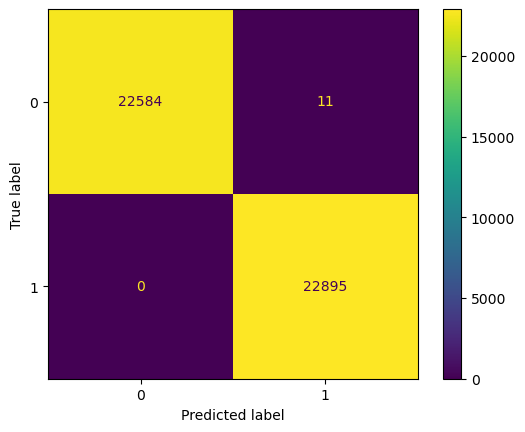

In [ ]:
#plot confusion matrix of above model
# In this case, false positive is better than false negative because missing a fraud is more damaging than
# predicting a normal transaction as fraud.
cm = confusion_matrix(y_valid, y_pred, labels=gbc_tuned.classes_)
color = 'white'
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=gbc_tuned.classes_)
disp.plot()
plt.show()